# Final Ranking
Using the results from the previous analysis we will join all the rankings and determine, how we are going to rank the merchants.

In [119]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os, sys
import re
import glob
import math
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pyspark.sql.functions as F
import sklearn
import traceback
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from datetime import datetime, timedelta
from collections import defaultdict
from multiprocessing import Manager
from xgboost import plot_importance, XGBRegressor
from pyspark.sql.window import Window
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [120]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

**Explore rankings created for merchants, determine importance of these features.**

In [121]:
# rankings of merchants by dollar value and number of transactions
r1 = spark.read.parquet("../data/curated/rankings_by_dollar_value.parquet")
r2 = spark.read.parquet("../data/curated/rankings_by_num_transactions.parquet")

print("Ranking 1 (dollar value):", r1.count(), "rows")
print("Ranking 2 (num transactions):", r2.count(), "rows")
print("Unique merchants en R1:", r1.select("merchant_abn").distinct().count())
print("Unique merchants en R2:", r2.select("merchant_abn").distinct().count())

r1.printSchema()
r2.printSchema()

Ranking 1 (dollar value): 4026 rows
Ranking 2 (num transactions): 4026 rows
Unique merchants en R1: 4026
Unique merchants en R2: 4026
root
 |-- merchant_abn: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- total_dollar_value: double (nullable = true)
 |-- num_transactions: long (nullable = true)
 |-- rank_take_rate: integer (nullable = true)
 |-- rank_dollar_value: integer (nullable = true)
 |-- avg_rank: double (nullable = true)

root
 |-- merchant_abn: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- total_dollar_value: double (nullable = true)
 |-- num_transactions: long (nullable = true)
 |-- rank_take_rate: integer (nullable = true)
 |-- rank_num_transactions: integer (nullable = true)
 |-- avg_rank: double (nullable = true)



In [122]:
# Join both rankings
# Keep the shared columns once, and rename each avg_rank so they don't collide
r1_clean = r1.select(
    "merchant_abn", "take_rate", "total_dollar_value", "num_transactions",
    "rank_take_rate", "rank_dollar_value",
    F.col("avg_rank").alias("avg_rank_dollar"),
)

r2_clean = r2.select(
    "merchant_abn",
    "rank_num_transactions",
    F.col("avg_rank").alias("avg_rank_num_tx"),
)

rankings = r1_clean.join(r2_clean, on="merchant_abn", how="inner")

# the join should keep all 4,026 merchants and have no nulls
print("Rows after join:", rankings.count())
rankings.select(
    [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in rankings.columns]
).show()

# Spearman correlation between the three ranks (4,026 rows)
rankings_pd = rankings.toPandas()
rank_cols = ["rank_take_rate", "rank_dollar_value", "rank_num_transactions"]
print(rankings_pd[rank_cols].corr(method="spearman").round(3))

Rows after join: 4026
+------------+---------+------------------+----------------+--------------+-----------------+---------------+---------------------+---------------+
|merchant_abn|take_rate|total_dollar_value|num_transactions|rank_take_rate|rank_dollar_value|avg_rank_dollar|rank_num_transactions|avg_rank_num_tx|
+------------+---------+------------------+----------------+--------------+-----------------+---------------+---------------------+---------------+
|           0|        0|                 0|               0|             0|                0|              0|                    0|              0|
+------------+---------+------------------+----------------+--------------+-----------------+---------------+---------------------+---------------+

                       rank_take_rate  rank_dollar_value  \
rank_take_rate                  1.000              0.027   
rank_dollar_value               0.027              1.000   
rank_num_transactions           0.061              0.741 

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


**Features**
BNPL considers the amount of money they can recieve, for this reason we will calculate the estimated revenue as `take_rate × dollar value`.

In [123]:
# Percentile rank where ties get the same value (0 to 1, higher = better)
# gives same value to ties, and the average of the ranks for ties
rankings_pd["pct_take_rate"] = rankings_pd["take_rate"].rank(pct=True, method="average")
rankings_pd["pct_dollar_value"] = rankings_pd["total_dollar_value"].rank(pct=True, method="average")
rankings_pd["pct_num_tx"] = rankings_pd["num_transactions"].rank(pct=True, method="average")

In [124]:
# calculate estimated revenue for each merchant based on their take rate and total dollar value
rankings_pd["est_revenue"] = rankings_pd["take_rate"] / 100 * rankings_pd["total_dollar_value"]

cols = ["merchant_abn", "take_rate", "total_dollar_value", "num_transactions", "est_revenue"]
round_map = {"take_rate": 2, "total_dollar_value": 0, "est_revenue": 0}


print("Top 20 by dollar-value ranking")
print(rankings_pd.sort_values("avg_rank_dollar").head(20)[cols].round(round_map).to_string(index=False))

print("\nTop 20 by num-transactions ranking")
print(rankings_pd.sort_values("avg_rank_num_tx").head(20)[cols].round(round_map).to_string(index=False))

# How many of the top 100 are shared between both rankings
top100_r1 = set(rankings_pd.nsmallest(100, "avg_rank_dollar")["merchant_abn"])
top100_r2 = set(rankings_pd.nsmallest(100, "avg_rank_num_tx")["merchant_abn"])
print("\nShared merchants in both top 100:", len(top100_r1 & top100_r2))

Top 20 by dollar-value ranking
merchant_abn  take_rate  total_dollar_value  num_transactions  est_revenue
 45629217853       6.98           8395062.0            228255     585975.0
 12771097467       6.95           4932394.0              1340     342801.0
 35809331583       6.95           2730705.0              1828     189784.0
 79827781481       6.82           9734168.0              4798     663870.0
 71528203369       6.94           1879794.0             32404     130458.0
 58314972637       6.96           1471777.0              4397     102436.0
 98072939449       6.89           3588396.0              5948     247241.0
 16288327194       6.92           1652801.0              3737     114374.0
 45946543693       6.98           1411258.0              3745      98506.0
 31397959824       6.89           1488824.0              6063     102580.0
 81761494572       6.82           3031721.0             26265     206763.0
 13514558491       6.78           5630545.0             17900     381

In [125]:
# Show real take_rate values
print(rankings_pd["take_rate"].describe().round(2))

# Average ticket size per merchant
rankings_pd["avg_ticket"] = rankings_pd["total_dollar_value"] / rankings_pd["num_transactions"]

# How closely does each ranking follow estimated revenue (lower avg_rank = better,
# so we compare against -est_revenue to make both point the same way)
print("Spearman with est_revenue:")
print("  dollar ranking :", round(rankings_pd["avg_rank_dollar"].corr(-rankings_pd["est_revenue"], method="spearman"), 3))
print("  num_tx ranking :", round(rankings_pd["avg_rank_num_tx"].corr(-rankings_pd["est_revenue"], method="spearman"), 3))

# Overlap of each top 100 with the top 100 by estimated revenue
top100_rev = set(rankings_pd.nlargest(100, "est_revenue")["merchant_abn"])
print("Top 100 overlap with est_revenue ranking:")
print("  dollar ranking :", len(top100_r1 & top100_rev))
print("  num_tx ranking :", len(top100_r2 & top100_rev))

count    4026.00
mean        4.40
std         1.78
min         0.10
25%         2.97
50%         4.50
75%         6.03
max         7.00
Name: take_rate, dtype: float64
Spearman with est_revenue:
  dollar ranking : 0.875
  num_tx ranking : 0.705
Top 100 overlap with est_revenue ranking:
  dollar ranking : 25
  num_tx ranking : 19


The ranking of estimated revenue seems highly correlated with the dollar amount and number of transactions. However, among the top 100 merchants, the ones that generate the highest revenue don't necessarily overlap with those with higher dollar value and transaction volume.

In [126]:
top100_rev_df = rankings_pd.nlargest(100, "est_revenue")
missed = top100_rev_df[~top100_rev_df["merchant_abn"].isin(top100_r1)]

cols = ["merchant_abn", "take_rate", "total_dollar_value", "num_transactions",
        "est_revenue", "rank_take_rate", "rank_dollar_value"]
print("In top 100 by revenue but NOT in top 100 of the dollar ranking:", len(missed))
print(missed.sort_values("est_revenue", ascending=False).head(15)[cols].round(
    {"take_rate": 2, "total_dollar_value": 0, "est_revenue": 0}).to_string(index=False))

print("\nTake rate of the missed merchants:")
print(missed["take_rate"].describe().round(2))

In top 100 by revenue but NOT in top 100 of the dollar ranking: 75
merchant_abn  take_rate  total_dollar_value  num_transactions  est_revenue  rank_take_rate  rank_dollar_value
 96680767841       5.91           9806731.0             31134     579578.0            1147                  2
 21439773999       6.10           9426657.0            120624     575026.0             943                 14
 82368304209       5.55           9753248.0              5193     541305.0            1543                  4
 89726005175       6.01           8908823.0            215963     535420.0            1022                 26
 94493496784       5.65           9115636.0             99176     515033.0            1418                 21
 40515428545       5.89           7780713.0             13019     458284.0            1171                 44
 35909341340       4.80           9528214.0             37985     457354.0            1813                 12
 79417999332       4.95           9126403.0          

There are merchants that generate a high dollar value but have a low take rate. For this reason, we will use est_revenue as a feature because this will directly tell us whether a merchant is better based on the amount of money they generate for the BNPL company. In addition to this, we will use the number of transactions to add weight to the merchants that have higher demand. However, this feature will have less weight than est_revenue, since there can be a merchant with high demand but with small purchases.

In [127]:
rankings_pd["est_revenue"] = rankings_pd["take_rate"] / 100 * rankings_pd["total_dollar_value"]

print("Spearman est_revenue vs num_transactions:",
      round(rankings_pd["est_revenue"].corr(rankings_pd["num_transactions"], method="spearman"), 3))

Spearman est_revenue vs num_transactions: 0.717


**Check if estimated revenue is stable over time**

In [128]:
import pyspark.sql.functions as F

# Load only the columns needed for the stability check
df = (
    spark.read.parquet("../data/curated/final_external_enriched")
    .select("order_datetime", "merchant_abn", "dollar_value", "take_rate")
)

# Revenue per merchant in the train period and in the test period
train_cut = "2022-04-27"
test_cut = "2022-07-27"

# calculate estimated revenue per merchant in a given period
def revenue_by_period(spark_df):
    return spark_df.groupBy("merchant_abn").agg(
        (F.first("take_rate") / 100 * F.sum("dollar_value")).alias("est_revenue")
    )

rev_train = revenue_by_period(df.filter(F.col("order_datetime") <= train_cut)).withColumnRenamed("est_revenue", "rev_train")
rev_test = revenue_by_period(df.filter(F.col("order_datetime") > test_cut)).withColumnRenamed("est_revenue", "rev_test")

rev = rev_train.join(rev_test, "merchant_abn", "inner").toPandas()

print("Merchants in both periods:", len(rev))
print("Spearman train vs test revenue:", round(rev["rev_train"].corr(rev["rev_test"], method="spearman"), 3))

top_train = set(rev.nlargest(100, "rev_train")["merchant_abn"])
top_test = set(rev.nlargest(100, "rev_test")["merchant_abn"])
print("Top 100 overlap (train vs test):", len(top_train & top_test))

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Merchants in both periods: 3962
Spearman train vs test revenue: 0.976
Top 100 overlap (train vs test): 98


Estimated revenue is stable over time, since 98 of the 100 best merchants, stay as the best ones, over time. Hence, we will keep this feature for the final ranking model.

# See is_essential feature
We will check whether `is_essential` should affect the ranking, and how much weight it should get. We consider that a merchant is more valuable to BNPL when it has higher revenue, high demand and sells essential products, because its sales are more likely to be stable over time. Instead, if a merchant sells non-essential products and has low demand, then the merchant could be less reliable.

In [129]:
ess = (spark.read.parquet("../data/curated/merged_transactions_sa2.parquet")
       .select("merchant_abn", "is_essential").distinct().toPandas())

print("rows:", len(ess), "| merchants unique:", ess["merchant_abn"].nunique())

rankings_pd = rankings_pd.merge(ess, on="merchant_abn", how="left")
print("merchants:", len(rankings_pd), "| without is_essential:", rankings_pd["is_essential"].isna().sum())
print(rankings_pd["is_essential"].value_counts(dropna=False))

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


rows: 4026 | merchants unique: 4026
merchants: 4026 | without is_essential: 0
is_essential
not_essential    2715
borderline        699
essential         612
Name: count, dtype: int64


In [130]:
order = ["essential", "borderline", "not_essential"]
d = rankings_pd.copy()
d["avg_ticket"] = d["total_dollar_value"] / d["num_transactions"]

summary = d.groupby("is_essential").agg(
    merchants=("merchant_abn", "count"),
    revenue_total=("est_revenue", "sum"),
    revenue_median=("est_revenue", "median"),
    tx_median=("num_transactions", "median"),
    ticket_median=("avg_ticket", "median"),
).reindex(order)
summary["pct_revenue_total"] = summary["revenue_total"] / summary["revenue_total"].sum() * 100
print(summary.round(1))

# in what quadrant does each class fall? (cut at the median)
high_rev = d["est_revenue"] >= d["est_revenue"].median()
high_dem = d["num_transactions"] >= d["num_transactions"].median()
d["profile"] = np.select(
    [high_rev & high_dem, high_rev & ~high_dem, ~high_rev & high_dem],
    ["high revenue + high demand", "high revenue + low demand", "low revenue + high demand"],
    default="low revenue + low demand",
)
print("\n% of merchants in each profile:")
print((pd.crosstab(d["profile"], d["is_essential"], normalize="columns") * 100).round(1)[order])

               merchants  revenue_total  revenue_median  tx_median  \
is_essential                                                         
essential            612     14603439.8          5188.6      399.5   
borderline           699     17245965.3          5805.0      538.0   
not_essential       2715     64506219.4          5038.2      384.0   

               ticket_median  pct_revenue_total  
is_essential                                     
essential              327.2               15.2  
borderline             250.2               17.9  
not_essential          332.4               66.9  

% of merchants in each profile:
is_essential                essential  borderline  not_essential
profile                                                         
high revenue + high demand       40.7        44.2           38.0
high revenue + low demand         9.8         6.9           11.6
low revenue + high demand         8.3        11.0           10.9
low revenue + low demand         41.2    

It seems that the revenue and demand are similar in all groups, so being essential or not may not have an effect.

In [131]:
tx = (spark.read.parquet("../data/curated/final_external_enriched")
      .select("order_datetime", "merchant_abn", "dollar_value"))

monthly = (tx.groupBy("merchant_abn", F.date_trunc("month", "order_datetime").alias("month"))
             .agg(F.sum("dollar_value").alias("rev")))

# drop the first and last month, which are usually incomplete
b = monthly.agg(F.min("month").alias("first_m"), F.max("month").alias("last_m")).collect()[0]
monthly = monthly.filter((F.col("month") > b["first_m"]) & (F.col("month") < b["last_m"])).toPandas()

# coefficient of variation per merchant (lower = more stable)
cv = (monthly.groupby("merchant_abn")["rev"]
      .agg(months="count", mean="mean", std="std").reset_index())
cv["cv"] = cv["std"] / cv["mean"]
cv = cv[cv["months"] >= 6].merge(ess, on="merchant_abn")

print("merchants with CV:", len(cv))
print(cv.groupby("is_essential")["cv"].describe().round(3).reindex(["essential", "borderline", "not_essential"]))

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


merchants with CV: 3922
                count   mean    std    min    25%    50%    75%    max
is_essential                                                          
essential       597.0  0.383  0.203  0.147  0.213  0.322  0.526  1.336
borderline      698.0  0.352  0.181  0.147  0.208  0.290  0.450  1.045
not_essential  2627.0  0.393  0.213  0.134  0.217  0.321  0.523  1.714


/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


<Axes: title={'center': 'Monthly revenue by class (1.0 = average level for the first 6 months)'}, xlabel='month'>

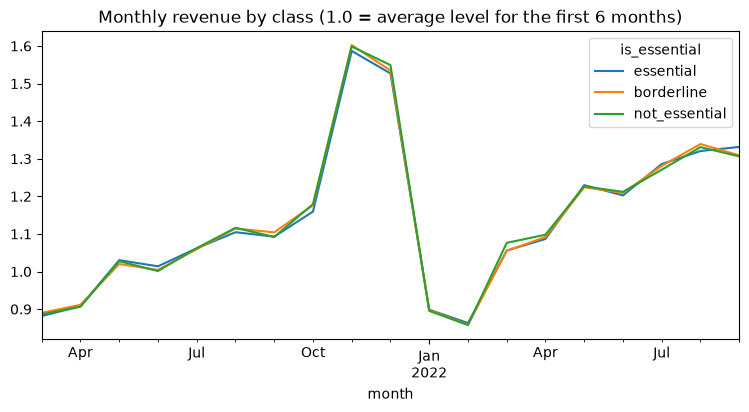

In [132]:
cm = (spark.read.parquet("../data/curated/final_external_enriched")
      .groupBy("merchant_abn", F.date_trunc("month", "order_datetime").alias("month"))
      .agg(F.sum("dollar_value").alias("rev"))
      .toPandas()
      .merge(ess, on="merchant_abn"))

trend = cm.groupby(["month", "is_essential"])["rev"].sum().unstack().iloc[1:-1]  
trend = trend / trend.iloc[:6].mean()      # 1.0 = average level for the first 6 months
trend[["essential", "borderline", "not_essential"]].plot(figsize=(9, 4),
      title="Monthly revenue by class (1.0 = average level for the first 6 months)")

The monthly revenue in each class is approximately the same for all cases. Therefore, we can't determine whether this feature can be used as planned. However, we will keep `is_essential` as a business decision, since we consider that consumers will keep buying essential products, regardless of circumstances, so their demand is expected to be more stable.

# Create Final ranking

In [133]:
# prepare features for the final ranking model
import numpy as np

# One row per merchant, ready to be merged with teammates' components
vol = rankings_pd[["merchant_abn", "take_rate", "total_dollar_value", "num_transactions"]].copy()
vol["est_revenue"] = vol["take_rate"] / 100 * vol["total_dollar_value"]

def log01(x):
    """Log-scale min-max score (0 to 1, higher = better)."""
    l = np.log(x)
    return (l - l.min()) / (l.max() - l.min())

assert (vol["est_revenue"] > 0).all() and (vol["num_transactions"] > 0).all()   # log needs positive values

vol["score_revenue"] = log01(vol["est_revenue"])
vol["score_demand"] = log01(vol["num_transactions"])

vol.to_parquet("../data/curated/volume_scores.parquet", index=False)
print(vol.describe().round(3))

       take_rate  total_dollar_value  num_transactions  est_revenue  \
count   4026.000            4026.000          4026.000     4026.000   
mean       4.398          535781.369          3381.688    23933.339   
std        1.783         1218830.985         14146.701    58499.471   
min        0.100           10064.934             1.000       12.313   
25%        2.970           36652.804            93.000     1470.211   
50%        4.500          141397.948           418.000     5146.421   
75%        6.030          628006.259          2057.500    22933.625   
max        7.000         9857402.328        289513.000   663870.290   

       score_revenue  score_demand  
count       4026.000      4026.000  
mean           0.565         0.481  
std            0.158         0.170  
min            0.000         0.000  
25%            0.439         0.360  
50%            0.554         0.480  
75%            0.691         0.607  
max            1.000         1.000  


In [134]:
print(vol[["score_revenue", "score_demand"]].describe().round(3))

       score_revenue  score_demand
count       4026.000      4026.000
mean           0.565         0.481
std            0.158         0.170
min            0.000         0.000
25%            0.439         0.360
50%            0.554         0.480
75%            0.691         0.607
max            1.000         1.000


# Segments
We use the unique values in `category_group`, and assign a segment depending in the type of tags that are sold.

In [135]:
# Map each of the 15 category_group values to one of 5 segments
segment_map = {
    "technology": "Technology & Media", "tv_media_telecom": "Technology & Media",
    "books_media_digital": "Technology & Media", "music": "Technology & Media",
    "furniture_home": "Home & Office", "gardening": "Home & Office",
    "office_stationery": "Home & Office",
    "jewelry": "Fashion, Beauty & Luxury", "health_beauty": "Fashion, Beauty & Luxury",
    "footwear": "Fashion, Beauty & Luxury",
    "gifts_hobby_novelty": "Leisure, Gifts & Art", "antiques_art_craft": "Leisure, Gifts & Art",
    "outdoor_supply": "Leisure, Gifts & Art",
    "vehicle": "Vehicles & Equipment", "equipment_rental_leasing": "Vehicles & Equipment",
}

# One row per merchant with its category_group
merchant_cat = (
    spark.read.parquet("../data/curated/final_external_enriched")
    .select("merchant_abn", "category_group")
    .distinct()
    .toPandas()
)

# Each merchant should have exactly one category_group
print("One category per merchant:", merchant_cat["merchant_abn"].is_unique)

merchant_cat["segment"] = merchant_cat["category_group"].map(segment_map)
print("Unmapped merchants:", merchant_cat["segment"].isna().sum())

# Attach segments to the volume scores and check how balanced they are
vol_seg = vol.merge(merchant_cat[["merchant_abn", "category_group", "segment"]],
                    on="merchant_abn", how="left")
print(vol_seg.groupby("segment").size().sort_values())

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


One category per merchant: True
Unmapped merchants: 0
segment
Vehicles & Equipment         455
Home & Office                676
Fashion, Beauty & Luxury     761
Leisure, Gifts & Art         936
Technology & Media          1198
dtype: int64


# Ranking
We give a 80% weight to revenue and 20% to demand. This is because it is expected that a BNPL company is more intrested in the amount of money that they get, rather than how much their merchant sells.

In [136]:
# Provisional weights. Components missing from the table are skipped automatically
weights = {"score_revenue": 0.80, "score_demand": 0.20}

def compute_score(table, weights):
    available = {c: w for c, w in weights.items() if c in table.columns}
    total = sum(available.values())          # re-normalise so weights add up to 1
    table = table.copy()
    table["score"] = sum(table[c] * w / total for c, w in available.items())
    return table

scored = compute_score(vol_seg, weights)

# Overall ranking (1 = best)
scored["rank_overall"] = scored["score"].rank(ascending=False, method="first").astype(int)
top100 = scored.nsmallest(100, "rank_overall")

# Ranking inside each segment (1 = best)
scored["rank_in_segment"] = (
    scored.groupby("segment")["score"].rank(ascending=False, method="first").astype(int)
)
top10_by_segment = (
    scored[scored["rank_in_segment"] <= 10]
    .sort_values(["segment", "rank_in_segment"])
)

show_cols = ["segment", "rank_in_segment", "merchant_abn", "category_group",
             "est_revenue", "num_transactions", "score"]
print(top10_by_segment[show_cols].round({"est_revenue": 0, "score": 3}).to_string(index=False))

# Sanity checks
print("\nTop 100 overall, merchants per segment:")
print(top100["segment"].value_counts())
print("\nOverlap of this top 100 with the top 100 by est_revenue alone:",
      len(set(top100["merchant_abn"]) & set(scored.nlargest(100, "est_revenue")["merchant_abn"])))

                 segment  rank_in_segment merchant_abn      category_group  est_revenue  num_transactions  score
Fashion, Beauty & Luxury                1  86578477987             jewelry     613411.0            272674  0.993
Fashion, Beauty & Luxury                2  48534649627       health_beauty     624755.0             66437  0.972
Fashion, Beauty & Luxury                3  49322182190             jewelry     498791.0             51903  0.952
Fashion, Beauty & Luxury                4  46804135891       health_beauty     206350.0            234434  0.911
Fashion, Beauty & Luxury                5  93558142492            footwear     301850.0             21838  0.901
Fashion, Beauty & Luxury                6  11439466003            footwear     278809.0             29888  0.900
Fashion, Beauty & Luxury                7  99976658299            footwear     227780.0             23148  0.881
Fashion, Beauty & Luxury                8  62224020443             jewelry     225705.0         

In [137]:
# Save this initial ranking so it is reproducible
scored.to_parquet("../data/curated/initial_ranking.parquet", index=False)

# How much does the top 100 change when we vary the demand weight?
base_top100 = set(scored.nsmallest(100, "rank_overall")["merchant_abn"])  # current 80/20 weights

rows = []
for w_demand in [0.0, 0.1, 0.2, 0.3, 0.5]:
    w = {"score_revenue": 1 - w_demand, "score_demand": w_demand}
    t = compute_score(vol_seg, w)
    top = t.nlargest(100, "score")
    rows.append({
        "demand_weight": w_demand,
        "overlap_with_80_20": len(set(top["merchant_abn"]) & base_top100),
        "vehicles_in_top100": int((top["segment"] == "Vehicles & Equipment").sum()),
        "avg_est_revenue_top100": round(top["est_revenue"].mean()),
    })
print(pd.DataFrame(rows).to_string(index=False))

 demand_weight  overlap_with_80_20  vehicles_in_top100  avg_est_revenue_top100
           0.0                  93                  10                  334409
           0.1                  96                  10                  333696
           0.2                 100                   9                  330876
           0.3                  98                   9                  326596
           0.5                  85                   5                  299154


In [138]:
vol_seg["avg_purchase_value"] = vol_seg["total_dollar_value"] / vol_seg["num_transactions"]

seg_stats = vol_seg.groupby("segment").agg(
    merchants=("merchant_abn", "count"),
    median_ticket=("avg_purchase_value", "median"),
    median_transactions=("num_transactions", "median"),
    median_revenue=("est_revenue", "median"),
)

# Spearman between revenue and demand inside each segment
seg_stats["rev_vs_demand_corr"] = pd.Series({
    seg: g["est_revenue"].corr(g["num_transactions"], method="spearman")
    for seg, g in vol_seg.groupby("segment")
})

print(seg_stats.round(2).sort_values("median_ticket"))

                          merchants  median_ticket  median_transactions  \
segment                                                                   
Fashion, Beauty & Luxury        761         207.93                483.0   
Technology & Media             1198         244.47                530.5   
Home & Office                   676         321.93                387.5   
Leisure, Gifts & Art            936         668.92                352.5   
Vehicles & Equipment            455        1036.31                204.0   

                          median_revenue  rev_vs_demand_corr  
segment                                                       
Fashion, Beauty & Luxury         4782.17                0.71  
Technology & Media               5069.86                0.77  
Home & Office                    5549.00                0.83  
Leisure, Gifts & Art             5229.09                0.64  
Vehicles & Equipment             5377.29                0.72  


To determine the weights, we have to consider the segments that will have a high demand, even if their items have a low purchase value. But we also have segments that sell a small number of objects for a higher price. This means that we can't give the same weight to demand for all segments, because some will be more penalised than they should be. Therefore, we will assign a lower weight to demand for the segments that generate high revenue but have a low number of transactions.

A segment will have a lower weight is the number of transactions doesn't affect the revenue.

In [139]:
# Segment-level medians
seg_stats = vol_seg.groupby("segment").agg(
    median_transactions=("num_transactions", "median"),
    median_revenue=("est_revenue", "median"),
)

# Distance to the best segment on each dimension (1 = same as the best)
seg_stats["transactions_ratio"] = seg_stats["median_transactions"] / seg_stats["median_transactions"].max()
seg_stats["revenue_ratio"] = seg_stats["median_revenue"] / seg_stats["median_revenue"].max()

# Demand is down-weighted only when the transaction gap is NOT matched by a revenue gap
seg_stats["demand_factor"] = (seg_stats["transactions_ratio"] / seg_stats["revenue_ratio"]).clip(upper=1)

BASE_DEMAND_WEIGHT = 0.20
seg_stats["demand_weight"] = BASE_DEMAND_WEIGHT * seg_stats["demand_factor"]
print(seg_stats.round(3).sort_values("demand_weight", ascending=False))

# Apply each segment's weight to its merchants
scored_seg = vol_seg.copy()
scored_seg["demand_weight"] = scored_seg["segment"].map(seg_stats["demand_weight"])
scored_seg["score"] = (
    (1 - scored_seg["demand_weight"]) * scored_seg["score_revenue"]
    + scored_seg["demand_weight"] * scored_seg["score_demand"]
)
scored_seg["rank_in_segment"] = (
    scored_seg.groupby("segment")["score"].rank(ascending=False, method="first").astype(int)
)

# Vehicles top 10, to compare with the version that used a fixed 80/20
print(scored_seg[(scored_seg["segment"] == "Vehicles & Equipment") & (scored_seg["rank_in_segment"] <= 10)]
      [["rank_in_segment", "merchant_abn", "est_revenue", "num_transactions", "score"]]
      .round({"est_revenue": 0, "score": 3}).to_string(index=False))

                          median_transactions  median_revenue  \
segment                                                         
Fashion, Beauty & Luxury                483.0        4782.166   
Technology & Media                      530.5        5069.857   
Home & Office                           387.5        5549.000   
Leisure, Gifts & Art                    352.5        5229.094   
Vehicles & Equipment                    204.0        5377.286   

                          transactions_ratio  revenue_ratio  demand_factor  \
segment                                                                      
Fashion, Beauty & Luxury               0.910          0.862          1.000   
Technology & Media                     1.000          0.914          1.000   
Home & Office                          0.730          1.000          0.730   
Leisure, Gifts & Art                   0.664          0.942          0.705   
Vehicles & Equipment                   0.385          0.969          0.397  

In [140]:
# Overall ranking with the segment-specific demand weights
scored_seg["rank_overall"] = scored_seg["score"].rank(ascending=False, method="first").astype(int)
top100_seg = scored_seg.nsmallest(100, "rank_overall")

print("Top 100 by segment (segment-specific weights):")
print(top100_seg["segment"].value_counts())

# Compare with the fixed 80/20 version and with ranking by revenue alone
print("\nOverlap with fixed 80/20 top 100:", len(set(top100_seg["merchant_abn"]) & base_top100))
print("Overlap with top 100 by est_revenue:",
      len(set(top100_seg["merchant_abn"]) & set(scored_seg.nlargest(100, "est_revenue")["merchant_abn"])))


Top 100 by segment (segment-specific weights):
segment
Leisure, Gifts & Art        30
Technology & Media          27
Home & Office               18
Fashion, Beauty & Luxury    15
Vehicles & Equipment        10
Name: count, dtype: int64

Overlap with fixed 80/20 top 100: 99
Overlap with top 100 by est_revenue: 94


In [141]:
top100_rev_only = scored_seg.nlargest(100, "est_revenue")
comparison = pd.DataFrame({
    "top100_revenue_only": top100_rev_only["segment"].value_counts(),
    "top100_segment_weights": top100_seg["segment"].value_counts(),
    "share_of_merchants_%": (scored_seg["segment"].value_counts(normalize=True) * 100).round(1),
})
print(comparison)

                          top100_revenue_only  top100_segment_weights  \
segment                                                                 
Fashion, Beauty & Luxury                   15                      15   
Home & Office                              19                      18   
Leisure, Gifts & Art                       29                      30   
Technology & Media                         27                      27   
Vehicles & Equipment                       10                      10   

                          share_of_merchants_%  
segment                                         
Fashion, Beauty & Luxury                  18.9  
Home & Office                             16.8  
Leisure, Gifts & Art                      23.2  
Technology & Media                        29.8  
Vehicles & Equipment                      11.3  


**Add the weight of is_essential feature**

In [142]:
e_map = {"essential": 1.0, "borderline": 0.5, "not_essential": 0.0}
s = scored_seg.drop(columns=["is_essential"], errors="ignore").merge(ess, on="merchant_abn", how="left")
s["score_essential"] = s["is_essential"].map(e_map)

# use the current top 100 (w = 0) as the baseline to compare against
# assign different weights to the essential score and see how much the top 100 changes
base_top = set(s.nlargest(100, "score")["merchant_abn"])    
rows = []
for w in [0, 0.01, 0.02, 0.03, 0.05, 0.10]:
    s["score_w"] = (1 - w) * s["score"] + w * s["score_essential"]
    top = s.nlargest(100, "score_w")
    rows.append({
        "w_essential": w,
        "same_as_current_top100": len(set(top["merchant_abn"]) & base_top),
        "essential_in_top100": int((top["is_essential"] == "essential").sum()),
        "borderline_in_top100": int((top["is_essential"] == "borderline").sum()),
        "avg_est_revenue_top100": round(top["est_revenue"].mean()),
    })
print(pd.DataFrame(rows))

   w_essential  same_as_current_top100  essential_in_top100  \
0         0.00                     100                   16   
1         0.01                     100                   16   
2         0.02                      98                   17   
3         0.03                      98                   17   
4         0.05                      95                   20   
5         0.10                      75                   40   

   borderline_in_top100  avg_est_revenue_top100  
0                    17                  332048  
1                    17                  332048  
2                    18                  332774  
3                    18                  332774  
4                    18                  331143  
5                    18                  301548  


We take 0.02 as the weight for the is_essential score, since increasing it, will reduce the revenue of the selected merchants. In addition to this only 9 merchants will change position, from this feature.

In [143]:
W_ESS = 0.02
s["score_w"] = (1 - W_ESS) * s["score"] + W_ESS * s["score_essential"]
s["rank_before"] = s["score"].rank(ascending=False, method="first").astype(int)
s["rank_after"]  = s["score_w"].rank(ascending=False, method="first").astype(int)

entered = s[(s["rank_after"] <= 100) & (s["rank_before"] > 100)]
left    = s[(s["rank_after"] > 100) & (s["rank_before"] <= 100)]
print("Enter: old ranking", entered["rank_before"].min(), "a", entered["rank_before"].max())
print("Exit:  new ranking",    left["rank_after"].min(),       "a", left["rank_after"].max())

Enter: old ranking 105 a 112
Exit:  new ranking 101 a 102


In [144]:
sc = s.sort_values("score", ascending=False).reset_index(drop=True)
print(sc.loc[[99, 143], "score"].round(4).tolist())

[0.8511, 0.8083]


Since the scores from 99 to 142 are close to each other, this shows how the ranking system is sensitive to change.